# Work Environment

## Editing Tools

For most programming languages, including Python, there are many tools you can use to write and run programs. Some of the code-editing development tools are full-featured integrated development environments (IDEs), some are lightweight code editors, while others are specialized development environment such as Jupyter and Google Colab.

- Full IDEs like **PyCharm**, IntelliJ, and Visual Studio are comprehensive environments designed for full-scale software development: building complete applications, managing large codebases, and collaborative development. They're the standard choice for professional software engineering where you need structure, performance, and the ability to handle complex projects. Full IDEs have comprehensive tooling: debuggers, refactoring, testing frameworks, and project management. They're heavier but more powerful for large projects. [PyCharm ](https://www.jetbrains.com/pycharm/) is a popular IDE for both learners and professionals, [VS Code](https://code.visualstudio.com/) is a code editor turned full IDE through extensions. 
 
- Code editors like Visual Studio Code (**VS Code**), Sublime Text, and Notepad++ are lightweight tools for writing and editing code with features like syntax highlighting and basic autocomplete. They're fast to start up, use minimal resources, and have simpler interfaces. Over time, some editors (e.g., VS Code) have evolved and can function as full IDEs. VS Code has even become the industry standard for general software development. According to the [2025 Stack Overflow Developer Survey](https://survey.stackoverflow.co/2025/), approximately 76% of professional developers and 78% of people learning to code use VS Code, making it the most used and most desired editor for several years running. 

| Feature | VS Code (Code Editor) | Full IDE |
|---------|----------------------|--------------------------------------|
| Startup Speed | Fast; lightweight | Slower; heavy resource usage |
| Language Support | General-purpose; supports features via plugins/extensions | Specialized; deep, native support for specific languages (e.g., C#, Java) |
| Setup | Requires manual setup/extensions for tasks | Ready for complex projects immediately after installation |
| Cost | Usually free | Often requires paid license for professional version |
| Examples | <img src="https://cdn.jsdelivr.net/gh/devicons/devicon/icons/vscode/vscode-original.svg" height="16"> <a href="https://code.visualstudio.com/" style="text-decoration:none">VS Code</a>, <img src="https://cdn.simpleicons.org/sublimetext" height="16"> <a href="https://www.sublimetext.com/" style="text-decoration:none">Sublime Text</a>, <img src="https://cdn.simpleicons.org/vim" height="16"> <a href="https://www.vim.org/" style="text-decoration:none">Vim</a>, <a href="https://www.nano-editor.org/" style="text-decoration:none">nano</a>, <img src="https://cdn.simpleicons.org/notepadplusplus" height="16"> <a href="https://notepad-plus-plus.org/" style="text-decoration:none">Notepad++</a> | <img src="https://cdn.simpleicons.org/pycharm" height="16"> <a href="https://www.jetbrains.com/pycharm/" style="text-decoration:none">PyCharm</a>, <img src="https://cdn.simpleicons.org/intellijidea" height="16"> <a href="https://www.jetbrains.com/idea/" style="text-decoration:none">IntelliJ</a>, <img src="https://cdn.jsdelivr.net/gh/devicons/devicon/icons/visualstudio/visualstudio-plain.svg" height="16"> <a href="https://visualstudio.microsoft.com/" style="text-decoration:none">Visual Studio</a> |

- **Jupyter Notebook** is a specialized development tool. It's an interactive, cell-based environment primarily designed for data analysis, scientific computing, and exploration. You write code in individual cells that you can execute independently, and results (including visualizations and formatted text) appear immediately inline below the cell. Jupyter supports mixing code, markdown documentation, equations, and outputs in a single document, making it excellent for data science.

As you progress in learning how to code, you may find VS Code and PyCharm more useful when you mainly work on coding rather than data flow and documentation. If you are just getting started, it is recommended that  you start with Jupyter Notebook.

## The File System

Unix-like operating systems (such as Unix, macOS, and Linux) are file-based, meaning the design principle dictates that everything in the system is a file, and the files are organized as a tree-like file system structure following the [Filesystem Hierarchy Standard](https://en.wikipedia.org/wiki/Filesystem_Hierarchy_Standard). In the CLI, a file **path** is then used to access a file or a directory/folder in the computer’s hierarchical file structure in the absence of a GUI. 

The file system tree-like directory structure begins with the **root** (represented by the `/` symbol) directory, which contains default first-level directories representing various functionalities as shown in {numref}`linux_directory_tree`. For example, the `bin` (binary) directory is hte standard location contains compiled executable programs (i.e., "binaries"), and the `dev` (device) directory contains device files allowing software to communicate with hardware as if they are standard text files.

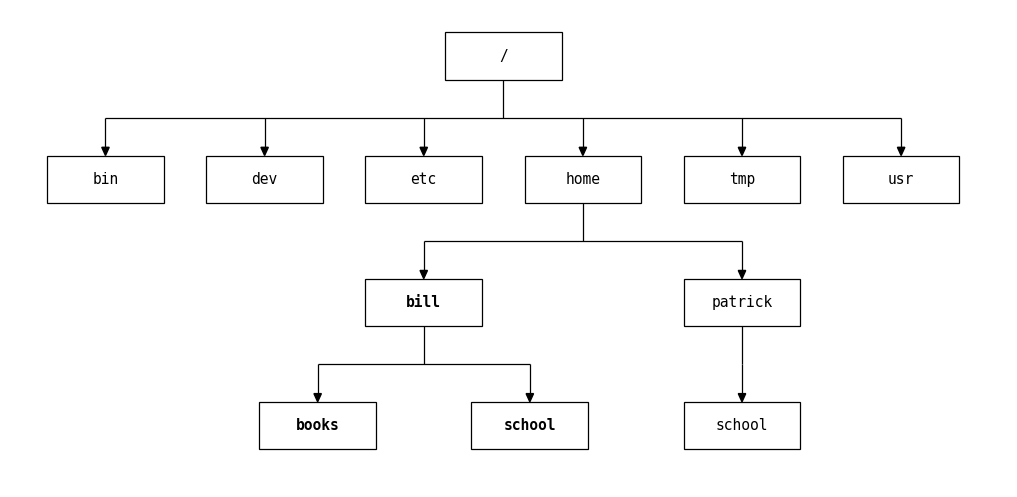

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.set_xlim(-0.4, 9.0)
ax.set_ylim(-0.1, 4.55)
ax.axis('off')

W, H   = 1.1, 0.46          # box width, height
lw     = 0.9
color  = 'black'
FONT   = 'monospace'
FS     = 10.5
AH, AW = 0.08, 0.07          # arrowhead height, width (data coords)

Y = [4.1, 2.9, 1.7, 0.5]    # row centre y-coords, top → bottom (tighter)

nodes = {                     # id: (cx, cy, label, bold)
    'root':    (4.25, Y[0], '/',       False),
    'bin':     (0.5,  Y[1], 'bin',     False),
    'dev':     (2.0,  Y[1], 'dev',     False),
    'etc':     (3.5,  Y[1], 'etc',     False),
    'home':    (5.0,  Y[1], 'home',    False),
    'tmp':     (6.5,  Y[1], 'tmp',     False),
    'usr':     (8.0,  Y[1], 'usr',     False),
    'bill':    (3.5,  Y[2], 'bill',    True),
    'patrick': (6.5,  Y[2], 'patrick', False),
    'books':   (2.5,  Y[3], 'books',   True),
    'school1': (4.5,  Y[3], 'school',  True),
    'school2': (6.5,  Y[3], 'school',  False),
}

tree = {                      # parent → ordered children
    'root':    ['bin', 'dev', 'etc', 'home', 'tmp', 'usr'],
    'home':    ['bill', 'patrick'],
    'bill':    ['books', 'school1'],
    'patrick': ['school2'],
}

BUS_Y = {k: (nodes[k][1] + nodes[v[0]][1]) / 2 for k, v in tree.items()}

kw = dict(color=color, lw=lw, solid_capstyle='butt', zorder=1)

# ── edges (all plain ax.plot lines; arrowheads are filled triangles) ──
for parent, children in tree.items():
    px, py, *_ = nodes[parent]
    bus_y = BUS_Y[parent]
    xs = [nodes[c][0] for c in children]

    ax.plot([px, px], [py - H/2, bus_y], **kw)                            # stem
    ax.plot([min(xs), max(xs)], [bus_y, bus_y], **kw)                     # bus
    if not (min(xs) <= px <= max(xs)):                                     # lateral if needed
        ax.plot([px, min(xs) if px < min(xs) else max(xs)], [bus_y, bus_y], **kw)

    for c in children:
        cx, cy, *_ = nodes[c]
        child_top = cy + H/2
        ax.plot([cx, cx], [bus_y, child_top + AH], **kw)                  # drop
        ax.add_patch(patches.Polygon(                                       # arrowhead
            [[cx, child_top],
             [cx - AW/2, child_top + AH],
             [cx + AW/2, child_top + AH]],
            closed=True, color=color, zorder=2))

# ── nodes ──
for nid, (cx, cy, label, bold) in nodes.items():
    ax.add_patch(patches.Rectangle(
        (cx - W/2, cy - H/2), W, H,
        linewidth=0.9, edgecolor=color, facecolor='white', zorder=3))
    ax.text(cx, cy, label, ha='center', va='center',
            fontfamily=FONT, fontweight='bold' if bold else 'normal',
            fontsize=FS, zorder=4)

plt.tight_layout(pad=0.1)
plt.show()

```{figure} ../../images/linux_directory_tree.gif
:name: linux_directory_tree
:alt: linux_directory_tree
:width: 75%
:align: center

[A Unix-Like File System Directory Tree Example](https://www.oreilly.com/openbook/debian/book/ch04_03.html)
```

One of the first-level directories requires your attention is the system's `home` (`Users` in macOS) directory, which contains user directories, specified as `/home/[username]`. Note that when you log into the system in terminal, this `/home/[username]` user home directory is your default working directory. In {numref}`linux_directory_tree`, there are two user directories ("bill" and "patrick") under the home directory, because Unix-like systems are designed to be multi-user environments. In modern Windows systems, the user home directory is `C:\User\[username]` and `/Users/[username]` in macOS.

The user home directories (e.g., `bill` and `patrick`) are user-specific personal directory that stores personal files, user data, and configuration settings (often hidden "`.`" files in Unix-like systems). The user home directory is created when creating the user account and is accessible to the user and users who are granted administrator privileges. The design of user home directories separates user data from system-wide data, which reduces system data redundancy and possible breaches at system level.

Similarly, in Windows, files and directories are organized in a hierarchical structure; except that drive letters such as `C:` and `D:` are used for separate file structure roots, while Linux uses a unified, hierarchical structure starting from a single **root** (/) for all drives and devices. In {numref}`windows11-directory-c-drive`, you see that, in File Explorer, if you click on `C:`, there is a number of folders and files organized under the `C:` drive, just like the root in Linux.

```{figure} ../../images/windows11-directory-c-drive.png
:name: windows11-directory-c-drive
:alt: windows11-directory-c-drive
:width: 75%
:align: center

Windows 11 Directory C: Drive
```

If you click to expand the `Users` folder, File Explorer will display the folders (usernames) contained within it. When you select to highlight a username, you will see all the files and directories of that user. In this example in {numref}`windows11-directory-user`, a folder called **`workspace`** is highlighted. 

Note that, in the CLI, this `C:\User\[username]` folder is the default location when a user first logs in, just like in the Unix-like systems. 

```{figure} ../../images/windows11-directory-user.png
:name: windows11-directory-user
:alt: windows11-directory-user
:width: 75%
:align: center

Windows 11 Directory Hierarchy from C: Drive to User Home Directory
```

## Command Line Basics

Having some knowledge of using the command line interface (CLI) is necessary when learning how to code. A CLI is often referred to, interchangeably, as the _command prompt_ in Windows, **shell** in Linux/macOS, or **command line** or **terminal** in general. Major operating systems (OSs) all have CLIs for users to interact with the operating system by issuing text commands in the CLI rather than using GUIs for speed, automation, and granular control. (For a discussion on terminology such as terminal, console, and shell, see [here](https://www.hanselman.com/blog/whats-the-difference-between-a-console-a-terminal-and-a-shell).


Different OSs are shipped with different CLIs, which include: 
- **Terminal**: A terminal is an application (or “terminal emulators” as they emulate the locally-attached dumb terminals) to access the shells.
- **Shell**: A shell is a command-line interface for the user to issue commands to the operating system.
- **REPL**: A REPL (Read–Eval–Print Loop) is an interactive programming environment for a specific language. 

In summary, terminals are programs like Windows PowerShell/Command Prompt, macOS Terminal.app, or Linux Terminal that you open to access the `shell`. A shell is a command-line **interpreter**. Note that a GUI is also considered a shell as it interfaces with the OS.

### Shell Languages

While a terminal can support multiple shells, each shell perfor`ms similar core functions interacting with the operating system. Major OSs and their default or commonly used shells are:

| OS | Terminal Emulator | Common Shell |
|---------|----------|----------------------------|
| Windows | Windows Terminal | PowerShell, Batch (command prompt, CMD) |
| macOS   | Terminal | Bash, Zsh              |
| Linux distributions |  GNOME, Konsole | Bash |

In addition, it is also common to refer to the CLI interpreter of a computer programming language as `shell`, such as Python shell for Python or [`CSharpRepl`](https://github.com/waf/CSharpRepl) for C#.

To start a **terminal session** in Windows, you search for *PowerShell*, and you will see **Windows PowerShell** as an App. For macOS/Linux, you search for **Terminal.app**. You then mouse-click on the application or press _Enter_ to open the terminal application and access the shell.

In the shell, you see a **command prompt** (e.g., `[user]@[computer]:~$` for macOS/Linux or `C:\Users\[user]>` for Windows), followed by a cursor (may blink), which indicates where you type to issue your commands for execution.

### Commands and Special Characters

To navigating around the file system directory structure, the essential commands below are helpful.

- `ls` (list storage) to show the files and directories in the current directory
- `cd` *path* (change directory) to change in the path directory in the directory tree structure (path “..” means the upper level directory).
- `touch` *filename* to create an empty file.
- `rm` *filename* to remove a file.
- `mkdir` *foldername* (make directory) to create an empty directory.
- `pwd` (print working directory) to see the full path of the current location.
- `cat` *filename* to display the contents of a file.
- `cp` *source_file destination* to copy a file
- `^+C` (hold the Control key and then hit the C key) to terminate a process.
- `exit` to exit out of the terminal app.

When you open the CLI terminal application, you mainly use the keyboard, rather than a mouse, to issue text commands (you can still mostly use the mouse to highlight and copy/paste text). In order to do that, some special pathname characters are commonly used (and are supported by major shells such as Bash and PowerShell):

- `/` is the root of the system’s file directory tree structure
- `~` is the user’s home directory
- `..` is the pathname of the directory one level up from the current directory
- `.` means the current directory, but when placed at the beginning of a file, it makes the file a hidden file.

For example, suppose that you are in certain location in the file system directory structure (e.g., workspace) and you would like to move to the root (`\`) of the system to check some files there. After that, you would like to come back to the user home directory, and then move into the `workspace\dsm\` directory, you would issue CLI commands as below. 

```powershell
PS C:\Users\tychen> cd .\workspace\
PS C:\Users\tychen\workspace> cd \
PS C:\> cd ~
PS C:\Users\tychen> cd .\workspace\dsm\
PS C:\Users\tychen\workspace\dsm>
```

In Windows, if you type the command `ls` and hit Enter to list storage, you see the directories and files listed:

```powershell
PS C:\Users\[user]> ls
    Directory: C:\Users\[user]
Mode                 LastWriteTime         Length Name
----                 -------------         ------ ----
d-----        12/25/2025  10:46 PM                .dotnet
d-----         8/30/2025  10:25 PM                .ipython
d-----         8/31/2025  10:53 AM                .jupyter
d-----         9/11/2025  12:01 AM                .ssh
d-----          9/4/2025   7:59 PM                .vscode
d-r---         8/30/2025   5:52 PM                Contacts
d-r---         9/11/2025  12:35 AM                Desktop
d-----         9/12/2025  10:27 AM                Documents
...
...
```

or, if you issue the same `ls` command in your macOS shell (default zsh or bash):

```bash
[user]@computer:~$ ls
Applications Documents    Google Drive Library      Music        Public       teaching     workspace
Desktop      Downloads    GoogleDrive  Movies       Pictures     research     temps
[user]@computer:~$ 
```

To see the file details like in PowerShell, you need to issue the `ls` command with the _long format_ option `-l`:

```bash
[user]@[computer]:~$ ls -l 
total 0
drwxr-xr-x   10 [user]  staff   320 Dec 18 15:14 Applications
drwx------@  58 [user]  staff  1856 Dec 19 15:50 Desktop
drwx------@  11 [user]  staff   352 Oct  2 22:46 Documents
drwx------@ 271 [user]  staff  8672 Dec 28 22:36 Downloads
lrwx------    1 [user]  staff    66 Dec 27 09:56 Google Drive -> /Users/[user]/Library/CloudStorage/GoogleDrive-[user]@gmail.com
drwxr-xr-x@  21 [user]  staff   672 Dec 27 09:56 GoogleDrive
drwx------+ 139 [user]  staff  4448 Oct  6 17:41 Library
...
...
```

## The Python Shell

While shell languages such as bash and PowerShell communicate with operating systems, a programming language may have its own "shell" or **REPL** (Read-Eval-Print Loop), which serves as a command-line interactive environment for running code written in the programming language. This means that when you type code, the REPL interprets it and displays the results immediately. A REPL perfect for testing snippets, learning syntax, and exploring modules without creating files. Different languages have different REPLs, for example:

| Language  | REPL   |
|-----------|--------|
| Python    | Python shell |
| Java      | JShell   |
| C#        | CSharpRepl |

The Python interpreter features a built-in interactive shell (the **Python shell** or "the interpreter"), which is the standard Python REPL and is widely used for quickly testing code. To access the Python shell, you can start your terminal (PowerShell in Windows Terminal or Terminal in macOS) and type `python` or `python3` with Enter. You will see the primary prompt (aka, chevrons), <span style="color: white; background:darkblue">**>>>**</span>, where you input code for immediate evaluation from the interpreter:  

````{tab-set}
```{tab-item} Windows
```powershell
PS C:\Users\[user]> python
Python 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)] on win32
Type "help", "copyright", "credits" or "license" for more information.
>>> 1 + 1
2
>>>
```

```{tab-item} macOS
```bash
[user]@[computer]:~$ python3
Python 3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 (clang-1700.3.19.1)] on darwin
Type "help", "copyright", "credits" or "license" for more information.
>>> 1 + 1
2
>>> 
```
````

In the Python shell, you may start experiencing Python programming by printing "hello, world":

````{tab-set}
```{tab-item} Windows
```powershell
PS C:\Users\[user]> python
Python 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)] on win32
Type "help", "copyright", "credits" or "license" for more information.
>>> print("hello, world")
hello, world
>>>
```

```{tab-item} macOS
```bash
[user]@[computer]:~/workspace/dsm$ python
Python 3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)] on darwin
Type "help", "copyright", "credits" or "license" for more information.
>>> print("hello, world")
hello, world
>>> 
```
````